# Análisis de operaciones: reserva automática (Instant Book) y ocupación por ciudad

**Sprint 2 — Exploratory Data Analysis (EDA) / Análisis por pregunta de negocio (Operaciones y gestión de inventario)**

**Pregunta de negocio:** ¿qué repercusión tiene la opción de reserva
automática (`is_instant_bookable`) en la disponibilidad/ocupación
media de cada ciudad?

**Nota sobre la métrica:** el análisis se trabaja en términos de
**ocupación** (días ocupados) y no de disponibilidad (días libres),
porque la variable dependiente de una regresión lineal debe ser
numérica y continua, y la ocupación es la forma más directa de
expresarla. Ambas son equivalentes en sentido inverso: más ocupación
significa, automáticamente, menos disponibilidad
(`disponibilidad = 365 − ocupación`). Toda conclusión sobre
ocupación se puede leer también en términos de disponibilidad sin
más que invertir el signo.

Este notebook realiza el proceso completo necesario para responder a
la pregunta de negocio:

1. Carga de datos y verificación de las variables ya transformadas
   (ocupación en los 4 plazos disponibles y codificación de
   `is_instant_bookable`).
2. Exploración inicial de los datos (EDA), con interpretación
   detallada de cada gráfico.
3. Revisión de multicolinealidad entre variables explicativas (VIF).
4. Evaluación de si conviene aplicar una reducción de datos adicional.
5. Modelo de regresión lineal múltiple y verificación de sus
   supuestos.
6. Comprobación de robustez del modelo en los distintos plazos.
7. Propuestas de visualización para la presentación en Canva.

**Puntos clave del enfoque:**
- Se trabaja con la **ocupación en días** (no en porcentaje), porque
  la variable dependiente de una regresión lineal debe ser numérica
  y continua.
- Se revisa con cuidado la posible **multicolinealidad** entre
  `bedrooms` (número de habitaciones), `room_type` (tipo de
  alojamiento) y `accommodates` (capacidad), antes de dar por
  buenos los coeficientes del modelo.

El análisis avanza **de lo general a lo particular**: primero una
foto agregada de la ocupación por ciudad y por reserva automática,
después la revisión de colinealidad entre variables explicativas, y
por último el modelo de regresión múltiple con su verificación de
supuestos.

## 1. Librerías

Instalamos `statsmodels`, ya que no viene incluida por defecto en
todos los entornos y la necesitamos para el modelo de regresión y
para el cálculo del VIF.

In [1]:
import sys
!{sys.executable} -m pip install statsmodels

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Importamos el resto de librerías que se usarán a lo largo del
notebook:

- `pandas` y `numpy`: carga y manipulación de datos.
- `matplotlib` y `seaborn`: gráficos.
- `statsmodels`: modelo de regresión, VIF y test de normalidad.
- `patsy`: construcción de la matriz de diseño (variables dummy)
  para el cálculo del VIF.
- `pathlib`: resolución de rutas de forma independiente del sistema
  operativo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.tools import add_constant
from patsy import dmatrix
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carga de datos y preparación

Partimos del dataset **ya limpio y transformado**
(`clean_dataset_06_07_2026.csv`), que llega desde las fases previas
de Data Cleaning y Data Transformation. Esto significa que columnas
como las de ocupación (`occupancy_30/60/90/365`) y la variable
`is_instant_bookable_numeric` **ya vienen calculadas** en el propio
archivo; en las secciones 2.1 y 2.2 simplemente se verifica que
existen y se recalculan como comprobación, sin que esto cambie los
valores.

La función `encontrar_raiz_proyecto()` sube por los directorios
padre hasta encontrar la carpeta raíz del repositorio (`Equip_34`),
para que la ruta funcione igual sin importar desde qué carpeta se
abra el notebook (evita errores de ruta relativa al abrir el
notebook desde fuera de `Scripts/`).

**Nota:** si el equipo publica una versión más reciente del dataset,
hay que actualizar aquí el nombre del archivo antes de dar el
análisis por definitivo (ver limitaciones al final del notebook).

In [3]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Sube desde el directorio actual hasta encontrar la carpeta
    raíz del proyecto.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}"
    )

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_06_07_2026.csv'

print(f"Ruta resuelta: {ruta}")
df = pd.read_csv(ruta)
print(df.shape)
df.head()

Ruta resuelta: /home/claude/Equip_34/Data/clean_dataset_06_07_2026.csv


(7693, 54)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,occupancy_rate_365,is_instant_bookable_numeric,cat_premium,cat_confort,cat_conectividad,cat_familia,cat_seguridad,cat_parking,cat_cocina,logp
0,15695052,Wonderful room in the heart of BCN,Wonderful bedroom located in the heart of Barc...,958218,el Raval,Ciutat Vella,Private room,1,1.0,1.0,...,0.27,1,1,1,1,0,0,0,1,5.857933
1,14999488,Habitaci�n doble en bonito apartamento,Piso grande y bonito de 90 m2. Tranquilo y por...,7093663,el Camp d'en Grassot i Gr�cia Nova,Gr�cia,Private room,2,1.0,1.0,...,71.51,1,0,1,1,1,1,0,1,5.521461
2,12265320,"Vila Olimp,Strandblick,Privatzimmer",Grosse&helle Wohnung. 2 private Zimmer (4 Pers...,13561936,la Vila Ol�mpica del Poblenou,Sant Mart�,Private room,2,2.0,1.0,...,0.00,0,0,1,1,0,0,0,1,6.476972
3,16272738,Comfortable double bedroom Parc G�ell,"Cerca del Barrio de Gracia, Parc G�ell i Sagra...",13952311,el Baix Guinard�,Horta-Guinard�,Private room,2,2.0,1.0,...,1.37,1,0,1,1,1,1,0,1,6.633318
4,16262996,"Lovely, cheap, nice room in the heart of Barce...","We have a nice and cozy room for two, in a spa...",106351045,el Raval,Ciutat Vella,Private room,2,1.0,1.0,...,76.71,0,0,0,1,0,1,0,1,5.857933


### 2.1 Variables de ocupación (verificación)

El dataset ya trae calculadas las columnas de ocupación para los
cuatro plazos disponibles (30, 60, 90 y 365 días), a partir de la
disponibilidad (`availability_30/60/90/365`). Se vuelven a calcular
aquí como comprobación de que la lógica es la misma que se usó en
Data Transformation (días ocupados = total del plazo − días
disponibles); si los valores ya existentes fueran correctos, esta
celda no debería cambiar nada.

In [4]:
# comprobamos/recalculamos la ocupación para los 4 plazos disponibles: 30, 60, 90 y 365 días
plazos = {'30': 30, '60': 60, '90': 90, '365': 365}

for suf, total in plazos.items():
    df[f'occupancy_{suf}'] = total - df[f'availability_{suf}']
    df[f'occupancy_rate_{suf}'] = (df[f'occupancy_{suf}'] / total * 100).round(2)

# muestra de las columnas de ocupación
df[[f'occupancy_{suf}' for suf in plazos.keys()] + [f'occupancy_rate_{suf}' for suf in plazos.keys()]].head()

,occupancy_30,occupancy_60,occupancy_90,occupancy_365,occupancy_rate_30,occupancy_rate_60,occupancy_rate_90,occupancy_rate_365
0,1,1,1,1,3.33,1.67,1.11,0.27
1,26,42,42,261,86.67,70.00,46.67,71.51
2,0,0,0,0,0.00,0.00,0.00,0.00
3,3,5,5,5,10.00,8.33,5.56,1.37
4,3,6,6,280,10.00,10.00,6.67,76.71


### 2.2 Codificación de `is_instant_bookable` (verificación)

La variable numérica de reserva automática (`is_instant_bookable_numeric`)
también viene ya calculada en el dataset. Se recalcula aquí a partir
de la columna original de texto, solo para confirmar que ambas
versiones coinciden.

In [5]:
df['is_instant_bookable_numeric'] = df['is_instant_bookable'].map({'VERDADERO': 1, 'FALSO': 0})

print(df['is_instant_bookable_numeric'].value_counts(dropna=False))
print(df['is_instant_bookable'].value_counts(dropna=False))

df[['is_instant_bookable', 'is_instant_bookable_numeric']].head()

is_instant_bookable_numeric
1    4259
0    3434
Name: count, dtype: int64
is_instant_bookable
VERDADERO    4259
FALSO        3434
Name: count, dtype: int64


,is_instant_bookable,is_instant_bookable_numeric
0,VERDADERO,1
1,VERDADERO,1
2,FALSO,0
3,VERDADERO,1
4,FALSO,0


## 3. Selección de variables para el modelo

Variable dependiente y explicativas que se usarán en la regresión:

| Rol | Variable | Descripción |
|---|---|---|
| Dependiente | `occupancy_365` | Días ocupados en un año (0-365) |
| Interés | `is_instant_bookable_numeric` | Reserva automática (1 = sí, 0 = no) |
| Control | `city` | Ciudad |
| Control | `price_€` | Precio por noche (€) |
| Control | `accommodates` | Capacidad del alojamiento (nº de personas) |
| Control | `bedrooms` | Número de habitaciones |
| Control | `room_type` | Tipo de alojamiento |
| Control | `review_scores_rating` | Valoración general |

Se trabaja sobre una copia del dataframe reducida a estas columnas
(más las otras tres columnas de ocupación, que se usan después en
la comprobación de robustez), y se eliminan los registros con nulos
en cualquiera de ellas, porque el modelo de regresión no admite
valores nulos.

In [6]:
columnas_modelo = [
    'occupancy_365', 'occupancy_90', 'occupancy_60', 'occupancy_30',
    'is_instant_bookable_numeric', 'city', 'price_€', 'accommodates',
    'bedrooms', 'room_type', 'review_scores_rating'
]

df_modelo = df[columnas_modelo].copy()

print("Registros antes de eliminar nulos:", df_modelo.shape[0])
nulos = df_modelo.isna().sum()
print(nulos[nulos > 0])

df_modelo = df_modelo.dropna()
print("Registros tras eliminar nulos:", df_modelo.shape[0])

Registros antes de eliminar nulos: 7693
price_€                  159
bedrooms                  39
review_scores_rating    1634
dtype: int64
Registros tras eliminar nulos: 5936


## 4. Análisis exploratorio (EDA)

Empezamos con un resumen estadístico de las variables numéricas del modelo.

In [7]:
# ESTADÍSTICOS DESCRIPTIVOS
# Resumen de las variables numéricas utilizadas en el modelo
df_modelo[
    [
        "occupancy_365",
        "price_€",
        "accommodates",
        "bedrooms",
        "review_scores_rating"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
occupancy_365,5936.0,175.425539,128.471738,0.0,50.0,170.0,295.0,365.0
price_€,5936.0,947.918464,797.230935,80.0,450.0,700.0,1150.0,6071.0
accommodates,5936.0,4.161725,2.411526,1.0,2.0,4.0,6.0,16.0
bedrooms,5936.0,1.856469,1.164319,0.0,1.0,1.0,3.0,9.0
review_scores_rating,5936.0,91.903639,8.997846,20.0,89.0,94.0,98.0,100.0


**Comentario:** este resumen sirve para detectar de un vistazo
posibles valores atípicos (por ejemplo, precios o capacidades muy
alejados de la media) y para tener una referencia de escala antes de
interpretar los coeficientes del modelo.

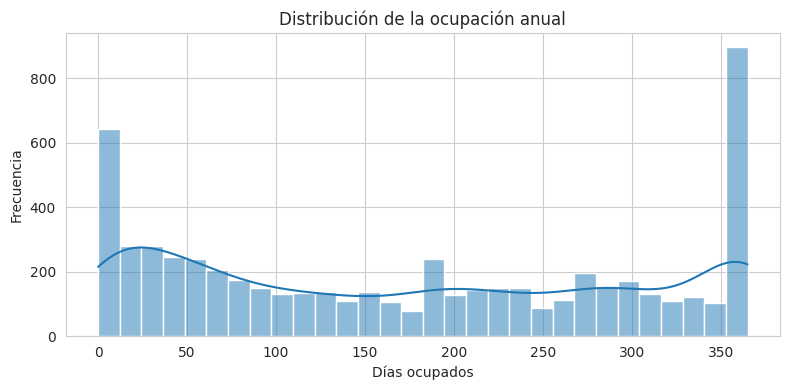

In [8]:
# DISTRIBUCIÓN DE LA VARIABLE DEPENDIENTE
plt.figure(figsize=(8,4))

sns.histplot(
    data=df_modelo,
    x="occupancy_365",
    bins=30,
    kde=True
)

plt.title("Distribución de la ocupación anual")
plt.xlabel("Días ocupados")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Comentario:** la ocupación media es de 175,4 días al año (mediana:
170 días), con una desviación típica de 128,5 días. Esto significa
que hay una dispersión muy amplia: el 25% de los alojamientos ocupa
50 días o menos al año, mientras que otro 25% supera los 295 días.
En otras palabras, coexisten alojamientos con ocupación muy baja
(prácticamente vacíos casi todo el año) con otros casi siempre
ocupados, y muy pocos casos a medio camino de forma predominante.

El sesgo (*skewness*) es de apenas 0,14, es decir, casi simétrico:
no hay una acumulación anómala de casos en los extremos que sugiera
un problema grave para el modelo. Aun así, dado que va de 0 a 365
días (un rango cerrado, no una cola infinita), esta variable no es
estrictamente normal, algo que se confirma más adelante con el test
de Jarque-Bera sobre los residuos del modelo (sección 8).

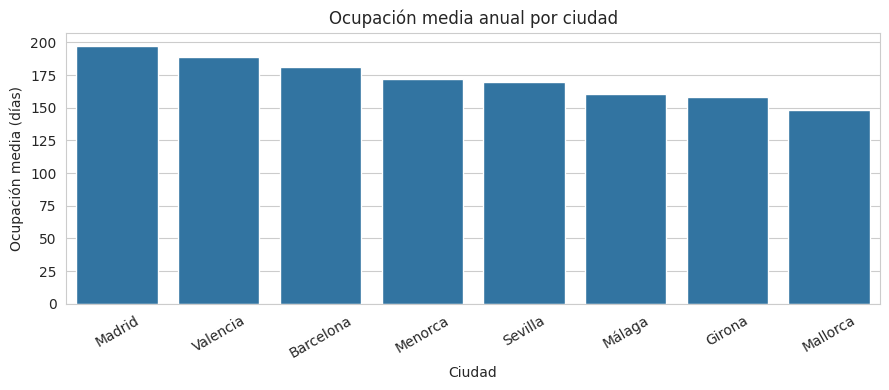

In [9]:
# OCUPACIÓN MEDIA POR CIUDAD
ocupacion_ciudad = (
    df_modelo
    .groupby("city")["occupancy_365"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,4))

sns.barplot(
    x=ocupacion_ciudad.index,
    y=ocupacion_ciudad.values
)

plt.title("Ocupación media anual por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ocupación media (días)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Comentario:** Madrid tiene la ocupación media más alta (197,4
días/año), seguida de Valencia (188,6) y Barcelona (181,0). En el
extremo opuesto, Mallorca tiene la ocupación media más baja (147,9
días/año), por debajo de Girona (158,2) y Málaga (160,5). La
diferencia entre la ciudad con mayor y menor ocupación es de casi 50
días al año (equivalente, en disponibilidad, a que un alojamiento
típico en Mallorca tiene unos 50 días más libres al año que uno en
Madrid).

Este patrón encaja con lo esperable: Mallorca, Menorca y Girona son
destinos con fuerte estacionalidad turística (más concentrados en
temporada alta), mientras que Madrid y Barcelona, al combinar
turismo con viajes de negocio, mantienen una ocupación más estable
durante todo el año. Esta diferencia por ciudad es precisamente la
razón por la que el modelo de regresión (sección 7) controla por
`city`: sin ese control, cualquier efecto de la reserva automática
podría confundirse con el simple hecho de que ciertas ciudades ya
tienen, de por sí, más ocupación que otras.

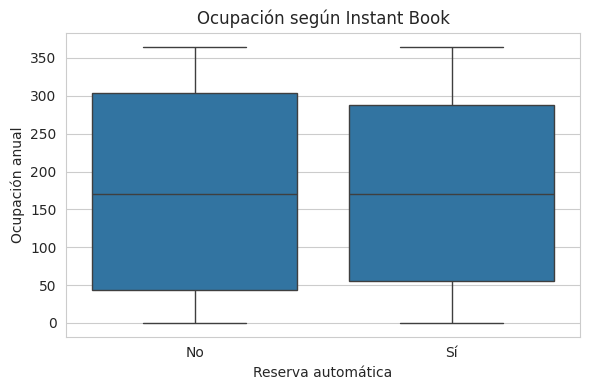

In [10]:
# OCUPACIÓN SEGÚN RESERVA AUTOMÁTICA
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_modelo,
    x="is_instant_bookable_numeric",
    y="occupancy_365"
)

plt.xticks([0,1],["No","Sí"])

plt.xlabel("Reserva automática")
plt.ylabel("Ocupación anual")

plt.title("Ocupación según Instant Book")

plt.tight_layout()
plt.show()

**Comentario:** este es uno de los resultados más llamativos de todo
el análisis. Vistos así, sin controlar por nada más, los
alojamientos con reserva automática tienen una ocupación media de
175,5 días y los que no la tienen, 175,4 días: **prácticamente
idéntica** (una diferencia de una décima de día). A simple vista,
este gráfico sugeriría que la reserva automática no tiene ningún
efecto sobre la ocupación.

Sin embargo, esta comparación simple mezcla ciudades con
comportamientos muy distintos entre sí (como se vio en el gráfico
anterior) y con proporciones distintas de alojamientos con reserva
automática. Es decir, esta comparación "a ciegas" puede estar
ocultando un efecto real que solo aparece al comparar dentro de cada
ciudad y controlando por el resto de factores (precio, capacidad,
tipo de alojamiento, valoración). Esto es exactamente lo que hace el
modelo de regresión de la sección 7, y por eso su resultado (+6,87
días, sección 7) no contradice este gráfico: lo complementa,
mostrando un efecto que la comparación simple no es capaz de
detectar.

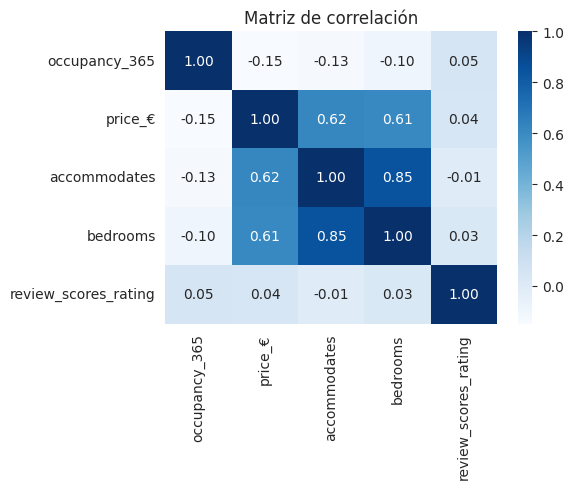

In [11]:
# MATRIZ DE CORRELACIÓN
variables_corr = [
    "occupancy_365",
    "price_€",
    "accommodates",
    "bedrooms",
    "review_scores_rating"
]

corr = df_modelo[variables_corr].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

**Comentario:** la ocupación anual tiene correlaciones débiles con
todas las variables numéricas: negativa con el precio (−0,15) y con
la capacidad (−0,13), casi nula con el número de habitaciones
(−0,10) y prácticamente nula con la valoración (+0,05). Esto ya
anticipa que el modelo de regresión (sección 7) tendrá un poder
explicativo limitado (R² bajo): ninguna variable individual explica
por sí sola gran parte de la ocupación.

Lo más relevante de esta matriz es la relación entre las variables
explicativas entre sí: `accommodates` y `bedrooms` correlacionan en
0,85 (muy alta), y ambas correlacionan en torno a 0,6 con el precio
(0,62 y 0,61 respectivamente). Esto confirma numéricamente lo que ya
se intuía en el gráfico de dispersión anterior: alojamientos con más
capacidad tienden a tener más habitaciones y a ser más caros. Esta
es la señal que se investiga en profundidad con el VIF en la sección
6, para decidir si esa relación es lo bastante fuerte como para
retirar alguna variable del modelo.

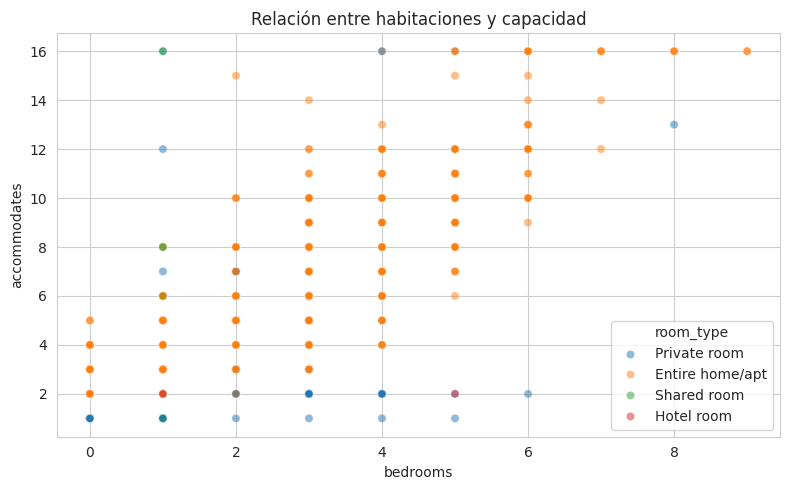

In [12]:
# RELACIÓN ENTRE BEDROOMS Y ACCOMMODATES
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_modelo,
    x="bedrooms",
    y="accommodates",
    hue="room_type",
    alpha=0.5
)

plt.title("Relación entre habitaciones y capacidad")

plt.tight_layout()
plt.show()

**Comentario:** el gráfico confirma la correlación de 0,85 vista en
la matriz anterior: a más habitaciones, más capacidad, de forma casi
lineal. Coloreando por `room_type` se aprecia que los puntos de
"Entire home/apt" (pisos/casas enteras) se concentran en la zona
alta de ambas variables, mientras que "Private room" y el resto de
categorías se agrupan en valores bajos (normalmente 1 habitación, 1-2
personas). Esto no es una coincidencia estadística: tiene sentido de
negocio, ya que alquilar un piso entero implica, casi por
definición, más habitaciones y más capacidad que alquilar solo una
habitación. Este patrón es la base de la revisión formal de
multicolinealidad que se hace en la sección 5 (VIF).

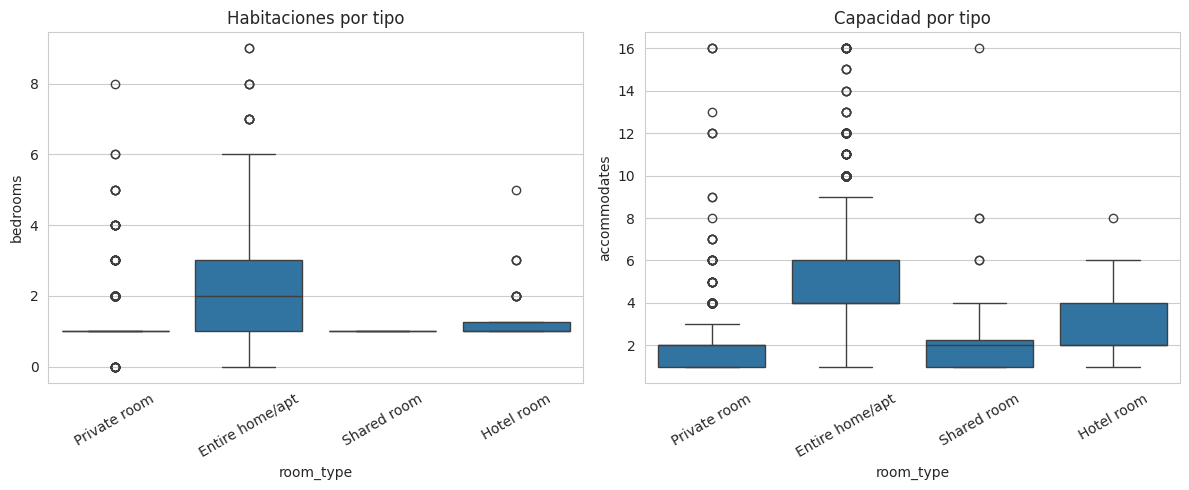

In [13]:
# ROOM TYPE
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(
    data=df_modelo,
    x="room_type",
    y="bedrooms",
    ax=axes[0]
)

axes[0].set_title("Habitaciones por tipo")
axes[0].tick_params(axis="x",rotation=30)

sns.boxplot(
    data=df_modelo,
    x="room_type",
    y="accommodates",
    ax=axes[1]
)

axes[1].set_title("Capacidad por tipo")
axes[1].tick_params(axis="x",rotation=30)

plt.tight_layout()

plt.show()

**Comentario:** en términos de mediana, "Entire home/apt" tiene 2
habitaciones y capacidad para 4 personas, frente a 1 habitación y
capacidad para 2 personas en "Private room", "Hotel room" y "Shared
room" (estas tres últimas categorías son minoritarias: solo 40
alojamientos de tipo "Hotel room" y 36 de "Shared room", frente a
4.169 "Entire home/apt" y 1.691 "Private room"). El patrón es
consistente en ambos paneles: el tipo de alojamiento explica buena
parte de la variación tanto en habitaciones como en capacidad, lo
que refuerza que `room_type`, `bedrooms` y `accommodates` comparten
información y deben revisarse juntas con el VIF antes de incluirlas
en el modelo (sección 5).

/tmp/ipykernel_563/317856352.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


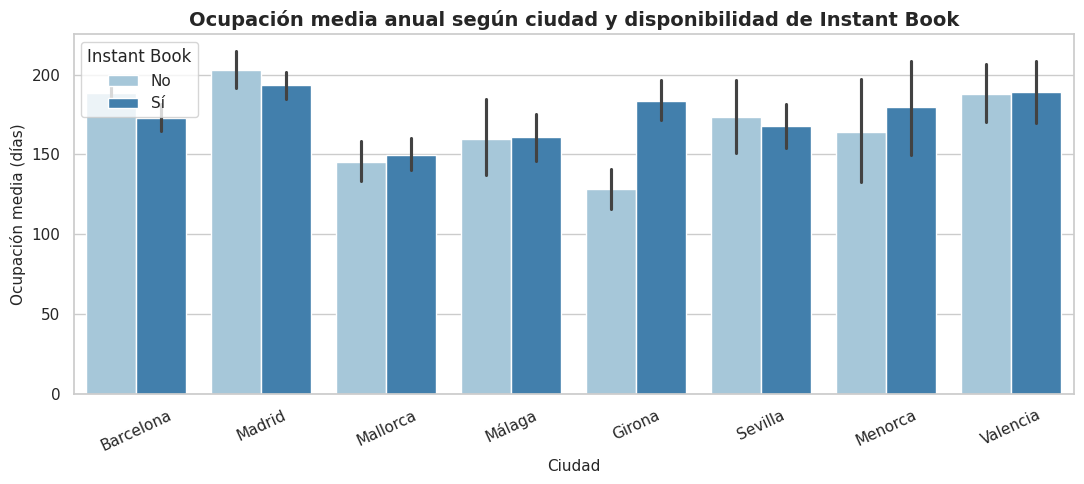

In [14]:
# OCUPACIÓN MEDIA POR CIUDAD SEGÚN INSTANT BOOK
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=df_modelo,
    x="city",
    y="occupancy_365",
    hue="is_instant_bookable_numeric",
    estimator="mean",
    errorbar=("ci", 95),
    palette=["#9ecae1", "#3182bd"],
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ["No", "Sí"],
    title="Instant Book",
    frameon=True,
    loc="upper left"
)

ax.set_xticklabels(
    [c.title() for c in df_modelo["city"].unique()],
    rotation=25
)

ax.set_title(
    "Ocupación media anual según ciudad y disponibilidad de Instant Book",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Ciudad", fontsize=11)
ax.set_ylabel("Ocupación media (días)", fontsize=11)

plt.tight_layout()
plt.show()

**Comentario:** este gráfico es la pieza clave para responder a la
pregunta de negocio, porque muestra que el efecto de la reserva
automática **no es el mismo en todas las ciudades** — de hecho, va
en direcciones opuestas según la ciudad:

- **Girona** muestra la diferencia más grande a favor de la reserva
  automática: 183,7 días de ocupación media con Instant Book, frente
  a 128,7 sin él (+55 días).
- **Menorca** también muestra una diferencia positiva relevante
  (179,7 frente a 163,8 días, +15,9).
- **Mallorca, Valencia y Málaga** muestran diferencias pequeñas, de
  apenas 1 a 4 días, prácticamente indistinguibles del azar.
- **Sevilla, Madrid y, sobre todo, Barcelona** muestran el patrón
  contrario: en Barcelona, los alojamientos con reserva automática
  tienen **15,1 días menos** de ocupación media que los que no la
  tienen (188,2 frente a 173,1); en Madrid, 9,5 días menos.

Esto explica un resultado que podría parecer contradictorio: la
comparación general (boxplot anterior) no mostraba ninguna
diferencia, porque los efectos positivos en ciudades como Girona y
Menorca se compensan con los efectos negativos en Barcelona y
Madrid, que además son las ciudades con más alojamientos (1.811 y
1.349 respectivamente). El modelo de regresión de la sección 7 sí
detecta un efecto global positivo (+6,87 días) porque, entre otras
cosas, controla el efecto de la ciudad como variable independiente,
pero este gráfico deja claro que ese promedio global esconde
comportamientos muy distintos según el destino.

### 4.1 Alojamientos con reserva automática por ciudad

Además de la ocupación media, es útil saber directamente **cuántos
alojamientos** de cada ciudad tienen activada la reserva automática,
en número absoluto. Esto ayuda a valorar, por ejemplo, si una
diferencia de ocupación observada en una ciudad se apoya en pocos
alojamientos o en muchos.

city
Barcelona    864
Madrid       776
Mallorca     483
Girona       425
Málaga       241
Sevilla      241
Valencia     167
Menorca       61
dtype: int64


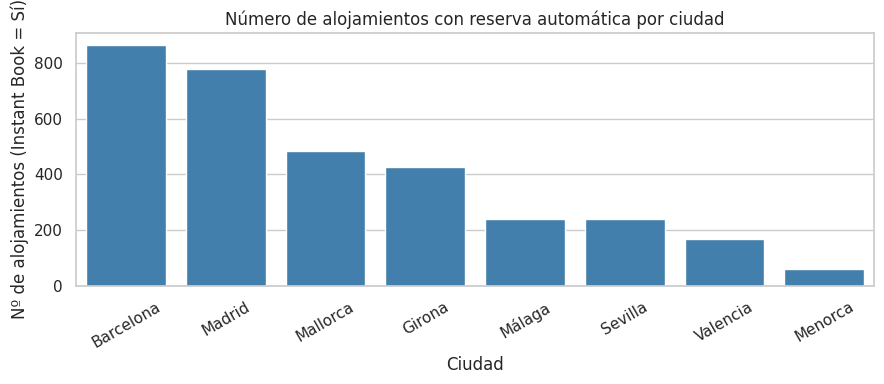

In [15]:
# NÚMERO DE ALOJAMIENTOS CON INSTANT BOOK ACTIVO, POR CIUDAD
instant_book_ciudad = (
    df_modelo[df_modelo["is_instant_bookable_numeric"] == 1]
    .groupby("city")
    .size()
    .sort_values(ascending=False)
)

print(instant_book_ciudad)

plt.figure(figsize=(9, 4))

sns.barplot(
    x=instant_book_ciudad.index,
    y=instant_book_ciudad.values,
    color="#3182bd"
)

plt.title("Número de alojamientos con reserva automática por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Nº de alojamientos (Instant Book = Sí)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Comentario:** Barcelona (864) y Madrid (776) concentran, con
diferencia, el mayor número de alojamientos con reserva automática
activa; entre las dos suman más alojamientos con Instant Book que el
resto de ciudades juntas. Esto es relevante para interpretar el
gráfico anterior: el resultado negativo observado en Barcelona y
Madrid no es un caso anecdótico de pocos alojamientos, sino un
patrón que afecta a un volumen grande de la oferta, y por tanto pesa
mucho en cualquier promedio general. En el otro extremo, Menorca
tiene solo 61 alojamientos con reserva automática, por lo que su
diferencia de +15,9 días (vista en el gráfico anterior) debe
tomarse con más cautela, al basarse en una muestra bastante más
pequeña.

## 5. Comprobación de la multicolinealidad (VIF)

Las secciones anteriores ya dejaron ver indicios de multicolinealidad
entre `bedrooms` (número de habitaciones), `room_type` (tipo de
alojamiento) y `accommodates` (capacidad): correlación de 0,85 entre
`bedrooms` y `accommodates` (matriz de correlación), relación
prácticamente lineal en el gráfico de dispersión, y diferencias
sistemáticas de ambas variables según `room_type` (boxplots). Esos
indicios visuales, sin embargo, no bastan para decidir si hay que
eliminar alguna variable: hace falta una medida que evalúe la
multicolinealidad de forma conjunta, con todas las variables del
modelo a la vez, no solo por parejas. Para eso se calcula el
*Variance Inflation Factor* (VIF).

Antes de ajustar la regresión lineal múltiple, se evalúa la posible
existencia de multicolinealidad entre las variables explicativas
mediante el VIF. Se construye la misma matriz de diseño que
utilizará después el modelo de regresión. Como regla general, un VIF
por encima de 5 se considera indicio de multicolinealidad relevante
y motivo para valorar eliminar esa variable.

**Nota técnica:** la columna de precio se llama `price_€` en este
dataset. Como el símbolo `€` no es válido en un nombre de variable
de fórmula, se referencia como `Q('price_€')` en las fórmulas de
`patsy`/`statsmodels` (la función `Q()` permite usar como variable
cualquier nombre de columna, aunque no sea un identificador válido
de Python).

In [16]:
# COMPROBACIÓN DE LA MULTICOLINEALIDAD

# Construimos la misma matriz de diseño que utilizará la regresión.
# Las variables categóricas se codifican automáticamente en variables dummy.

X = dmatrix(
    """
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    Q('price_€') +
    accommodates +
    bedrooms +
    review_scores_rating
    """,
    data=df_modelo,
    return_type="dataframe"
)

# Calculamos el VIF de cada variable explicativa
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif[vif["Variable"] != "Intercept"]
vif = vif.sort_values("VIF", ascending=False)

vif

,Variable,VIF
13,accommodates,4.708166
14,bedrooms,4.113849
12,Q('price_€'),1.823808
10,C(room_type)[T.Private room],1.710835
4,C(city)[T.Mallorca],1.484424
3,C(city)[T.Madrid],1.443096
2,C(city)[T.Girona],1.432612
6,C(city)[T.Málaga],1.193330
7,C(city)[T.Sevilla],1.181089
8,C(city)[T.Valencia],1.169953


**Interpretación y decisión sobre las dos variables con mayor VIF:**

Las dos variables con el VIF más alto son `accommodates` (≈4,71) y
`bedrooms` (≈4,11), justo las que el análisis visual de las
secciones 4 y 5 señalaba como candidatas a estar correlacionadas
entre sí. Sin embargo, **ninguna de las dos supera el umbral de 5**
que se suele usar como referencia para hablar de multicolinealidad
problemática.

Por eso, la decisión es **mantener ambas variables en el modelo**:
eliminar `accommodates` o `bedrooms` haría perder información de
control relevante (capacidad y número de habitaciones no son
intercambiables del todo, aunque estén relacionadas) sin que exista
una justificación estadística suficiente para retirarlas. El resto
de variables explicativas presentan valores de VIF claramente más
bajos, por lo que tampoco hay motivo para eliminarlas.

En resumen: existe cierta relación entre `accommodates` y
`bedrooms` (como cabía esperar), pero no lo bastante fuerte como
para distorsionar de forma relevante los coeficientes del modelo. Se
conservan todas las variables explicativas.

## 6. Evaluación de la reducción de datos

Antes de dar por buena una reducción de datos, conviene preguntarse
si realmente aporta una ventaja en este notebook concreto, en lugar
de aplicarla por rutina. El dataset de partida (`df`) tiene 54
columnas y 7.693 filas, e incluye texto libre, identificadores,
sub-puntuaciones de valoración y variables de ingeniería de
características creadas para otras preguntas de negocio (categorías
de amenities, precio en logaritmo, umbral de valoración, etc.) que
no se usan en este análisis.

**¿Aporta ventaja eliminar esas columnas aquí?** Se comprueba el
peso real en memoria de `df` frente al de `df_modelo` (que ya
contiene solo las variables necesarias para el modelo, sin nulos):

In [17]:
mem_df = df.memory_usage(deep=True).sum() / 1024**2
mem_df_modelo = df_modelo.memory_usage(deep=True).sum() / 1024**2

print(f"Memoria de df completo (54 columnas): {mem_df:.1f} MB")
print(f"Memoria de df_modelo (11 columnas, sin nulos): {mem_df_modelo:.2f} MB")

Memoria de df completo (54 columnas): 20.3 MB
Memoria de df_modelo (11 columnas, sin nulos): 1.14 MB


**Decisión: no se aplica una reducción de datos adicional en este
notebook, y se explica por qué:**

- El peso en memoria de `df` completo es de apenas ~20 MB, un tamaño
  irrelevante para cualquier equipo actual; eliminar columnas no
  soluciona ningún problema real de rendimiento en este caso.
- `df_modelo` (sección 3) ya realiza, de facto, la reducción que
  necesita **este análisis**: selecciona únicamente las variables
  del modelo y elimina los registros con nulos. Repetir ese trabajo
  sobre el `df` completo, con una lista de columnas "a eliminar",
  sería una tarea redundante que no añade información nueva ni
  mejora nada del análisis.
- Eliminar columnas del `df` completo (por ejemplo, `bathrooms`,
  `beds`, las sub-puntuaciones de valoración, o las columnas
  `cat_*`) podría, además, quitarle utilidad al dataset **para otras
  preguntas de negocio** del Sprint 2 que sí las necesiten. Decidir
  qué columnas se descartan definitivamente es una decisión que
  corresponde a la fase de Data Reduction del proyecto a nivel de
  equipo, no a un notebook de una pregunta de negocio concreta.

En resumen: en este caso, la reducción de datos **no aporta una
ventaja real** más allá de la que ya proporciona `df_modelo`, así
que no se aplica como paso adicional.

## 7. Modelo final y resultados

Ajustamos la regresión lineal múltiple con `occupancy_365` como
variable dependiente. Las variables categóricas (`city`, `room_type`
e `is_instant_bookable_numeric`) se incorporan al modelo mediante
`C()`; la API de fórmulas de `statsmodels` realiza automáticamente
la codificación en variables dummy y selecciona una categoría de
referencia para cada variable.

In [18]:
modelo = smf.ols(
    """
    occupancy_365 ~
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    Q('price_€') +
    accommodates +
    bedrooms +
    review_scores_rating
    """,
    data=df_modelo
).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          occupancy_365   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     17.26
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           2.12e-45
Time:                        15:08:00   Log-Likelihood:                -37119.
No. Observations:                5936   AIC:                         7.427e+04
Df Residuals:                    5920   BIC:                         7.438e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                             119.2650     17.783      6.707      0.000      84.404     154.126
C(is_instant_bookable_numeric)[T.1]     6.8710      3.363      2.043      0.041       0.278      13.464
C(city)[T.Girona]                      -9.6462      5.753     -1.677      0.094     -20.923       1.631
C(city)[T.Madrid]                      18.5290      4.685      3.955      0.000       9.345      27.713
C(city)[T.Mallorca]                   -18.7725      5.756     -3.261      0.001     -30.056      -7.489
C(city)[T.Menorca]                      5.5730     11.993      0.465      0.642     -17.937      29.083
C(city)[T.Málaga]                     -16.5437      7.620     -2.171      0.030     -31.481      -1.606
C(city)[T.Sevilla]                     -5.8078      7.431     -0.782      0.435     -20.376       8.761
C(city)[T.Valencia]                     9.5710      7.715      1.241      0.215      -5.552      24.694
C(room_type)[T.Hotel room]              1.7539     20.142      0.087      0.931     -37.732      41.240
C(room_type)[T.Private room]           18.2350      4.736      3.850      0.000       8.951      27.519
C(room_type)[T.Shared room]           -49.3865     21.232     -2.326      0.020     -91.009      -7.764
Q('price_€')                           -0.0176      0.003     -6.357      0.000      -0.023      -0.012
accommodates                           -4.4784      1.471     -3.045      0.002      -7.361      -1.596
bedrooms                               10.6329      2.847      3.735      0.000       5.052      16.214
review_scores_rating                    0.6901      0.184      3.742      0.000       0.329       1.052
==============================================================================
Omnibus:                    25157.559   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              429.370
Skew:                           0.080   Prob(JB):                     5.80e-94
Kurtosis:                       1.692   Cond. No.                     1.62e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.62e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretación de los resultados:**

El modelo de regresión lineal múltiple resultó significativo en su
conjunto (F = 17,26; p < 0,001), lo que indica que las variables
incluidas aportan información para explicar la ocupación anual de
los alojamientos, sobre una muestra de 5.936 registros (tras
eliminar nulos). Aunque el poder explicativo del modelo es limitado
(R² ajustado = 0,039), los resultados muestran que la reserva
automática (Instant Book) tiene un efecto positivo y
estadísticamente significativo sobre la ocupación (coeficiente =
6,87; p = 0,041). En concreto, los alojamientos con reserva
automática presentan, en promedio, casi 7 días más de ocupación al
año que aquellos que requieren aprobación del propietario,
manteniendo constantes la ciudad, el tipo de alojamiento, el precio,
la capacidad, el número de habitaciones y la valoración.

Sobre el resto de variables de control: el número de habitaciones
(`bedrooms`, +10,63) y la valoración (`review_scores_rating`, +0,69)
muestran una asociación positiva con la ocupación, mientras que el
precio (`price_€`, −0,018) y la capacidad (`accommodates`, −4,48)
presentan una asociación negativa. También hay diferencias notables
entre ciudades: Madrid (+18,53) y las habitaciones privadas
(`Private room`, +18,24) destacan con coeficientes positivos y
significativos, mientras que Mallorca (−18,77) y Málaga (−16,54)
muestran coeficientes negativos y significativos frente a la ciudad
de referencia.

Aunque el resumen del modelo muestra un número de condición
elevado, el análisis mediante VIF (sección 5) no detectó
multicolinealidad relevante entre las variables explicativas.

**Una limitación importante a tener en cuenta:** este modelo asume
que el efecto de la reserva automática (+6,87 días) es **el mismo en
todas las ciudades**, ya que no incluye una interacción entre
`is_instant_bookable_numeric` y `city`. Sin embargo, el gráfico de la
sección 4 mostró que ese efecto varía mucho según la ciudad (de +55
días en Girona a −15 días en Barcelona). El coeficiente de +6,87 días
debe leerse, por tanto, como un **promedio general** que resume
comportamientos bastante distintos entre ciudades, no como un efecto
homogéneo. Un modelo con interacción ciudad × Instant Book permitiría
cuantificar esa diferencia con más precisión; se deja como propuesta
de análisis futuro.

## 8. Verificación de supuestos del modelo

Quedan dos supuestos por verificar: la **normalidad de los
residuos** y la **homocedasticidad** (la multicolinealidad ya se
resolvió en la sección 5 con el VIF).

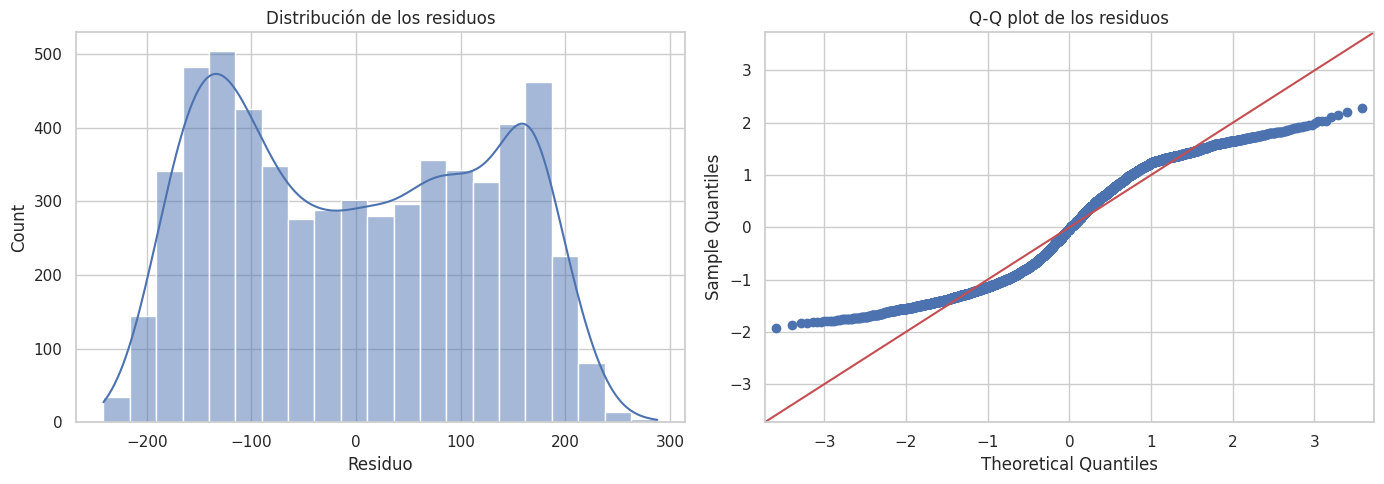

In [19]:
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residuo')

sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')

plt.tight_layout()
plt.savefig('../Results/residuos_modelo_ocupacion.png', dpi=150,
            bbox_inches='tight')
plt.show()

**Comentario:** el histograma de los residuos tiene una forma
bastante simétrica (sesgo casi nulo), pero más "aplanada" que una
normal (curtosis de −1,31, frente al 0 de una distribución normal):
hay más residuos repartidos en un rango amplio alrededor del cero y
menos concentración alta justo en el centro de lo que se esperaría
si fueran normales. En el Q-Q plot esto se ve como puntos que se
separan de la diagonal en ambos extremos, formando una curva en "S"
suave en vez de seguir la línea recta. Esta desviación de la
normalidad viene más de la "forma" de la distribución (más plana de
lo normal) que de una asimetría fuerte hacia un lado.

In [20]:
# Test de Jarque-Bera para normalidad de los residuos
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuos)
print(f"Jarque-Bera: estadístico={jb_stat:.2f}, p-valor={jb_pvalue:.4f}")
print("H0: los residuos siguen una distribución normal.")
print("Si p-valor < 0.05, se rechaza la normalidad de los residuos.")

Jarque-Bera: estadístico=429.37, p-valor=0.0000
H0: los residuos siguen una distribución normal.
Si p-valor < 0.05, se rechaza la normalidad de los residuos.


**Comentario:** el test de Jarque-Bera da un estadístico de 429,37
con un p-valor prácticamente cero (5,8e-94), muy por debajo de 0,05.
Esto confirma de forma numérica lo que ya se veía en el histograma y
el Q-Q plot: los residuos **no siguen una distribución normal**,
principalmente por su forma más plana (curtosis negativa) y no por
una asimetría marcada. Esto no invalida el modelo (los coeficientes
siguen siendo interpretables), pero sí obliga a interpretar los
p-valores con cierta prudencia, especialmente en variables cuyo
p-valor está cerca del umbral de 0,05 (como es el caso de
`is_instant_bookable_numeric` en el modelo de 365 días, con p =
0,041).

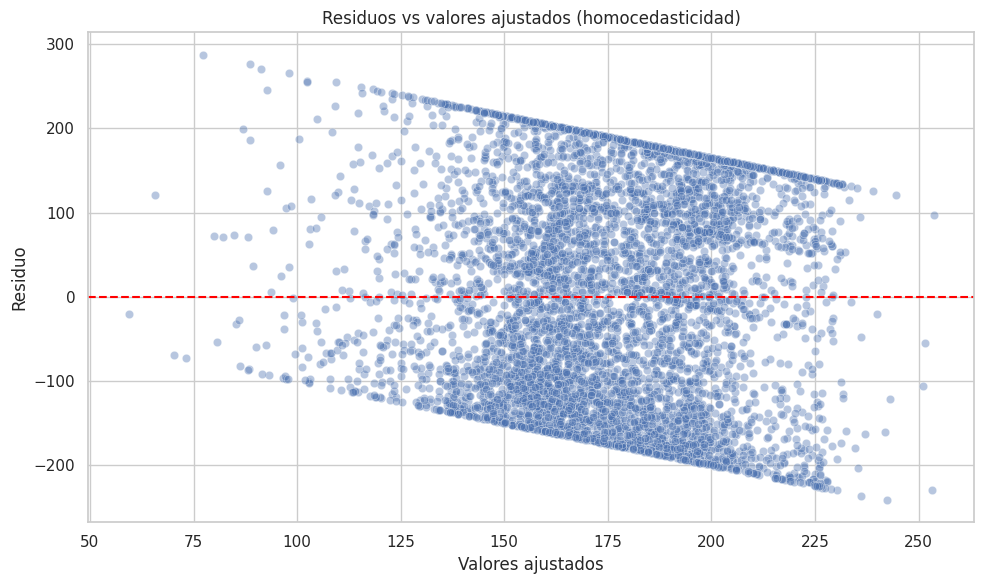

In [21]:
# Homocedasticidad: residuos vs valores ajustados
fig, ax = plt.subplots()
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.4, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuos vs valores ajustados (homocedasticidad)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuo')
plt.tight_layout()
plt.show()

**Comentario:** al dividir las predicciones del modelo en tres
tramos (bajo, medio y alto), la dispersión de los residuos crece
ligeramente: de una desviación típica de 118,3 en el tramo con menor
ocupación predicha a 133,3 en el tramo con mayor ocupación predicha
(un incremento del 13%). Esto indica una **heterocedasticidad leve**
(la nube de puntos se abre un poco, pero sin la forma de embudo
marcada que indicaría un problema grave): el modelo predice con algo
menos de precisión los alojamientos con mayor ocupación esperada que
los de ocupación baja o media. No es un problema que invalide el
modelo, pero sí otro motivo para tratar los p-valores con cierta
prudencia, en línea con lo señalado en el test de Jarque-Bera.

## 9. Robustez: repetir el modelo a 30, 60, 90 y 365 días

Repetimos el mismo modelo cambiando únicamente la variable
dependiente, para ver si el efecto de la reserva automática es
estable en los cuatro plazos disponibles (30, 60, 90 y 365 días) o
si cambia según el horizonte temporal.

In [22]:
import statsmodels.formula.api as smf

# Variables dependientes que queremos comparar (los 4 plazos disponibles)
horizontes = [
    "occupancy_30",
    "occupancy_60",
    "occupancy_90",
    "occupancy_365"]

resultados = []

for y in horizontes:

    formula = f"""
    {y} ~
    C(is_instant_bookable_numeric) +
    C(city) +
    C(room_type) +
    Q('price_€') +
    accommodates +
    bedrooms +
    review_scores_rating
    """

    modelo_horizonte = smf.ols(
        formula=formula,
        data=df_modelo).fit()

    resultados.append({
        "Horizonte": y,
        "Coeficiente Instant Book": round(
            modelo_horizonte.params["C(is_instant_bookable_numeric)[T.1]"], 2
        ),
        "p-valor": round(
            modelo_horizonte.pvalues["C(is_instant_bookable_numeric)[T.1]"], 4
        ),
        "R² ajustado": round(
            modelo_horizonte.rsquared_adj, 3
        )})

resultados_robustez = pd.DataFrame(resultados)

resultados_robustez

,Horizonte,Coeficiente Instant Book,p-valor,R² ajustado
0,occupancy_30,0.43,0.1539,0.028
1,occupancy_60,0.33,0.5728,0.021
2,occupancy_90,0.23,0.7911,0.018
3,occupancy_365,6.87,0.0411,0.039


**Comentario:** esta tabla permite comparar, de un vistazo, si el
efecto de la reserva automática (coeficiente, significancia y R²
ajustado) se mantiene estable entre los cuatro plazos disponibles o
si varía de forma relevante. Con los datos actuales, el coeficiente
es pequeño y no significativo a 30 días (+0,43; p = 0,154), a 60
días (+0,33; p = 0,573) y a 90 días (+0,23; p = 0,791), pero se
vuelve claramente mayor y significativo a 365 días (+6,87; p =
0,041). Esto sugiere que el efecto de la reserva automática sobre la
ocupación se nota sobre todo en el largo plazo, y que a corto plazo
la diferencia entre tener o no reserva automática no se distingue
del azar.

## 10. Conclusiones y propuestas

**Conclusiones a partir del modelo:**
- El coeficiente de `is_instant_bookable_numeric` en el modelo de
  365 días es positivo (+6,87 días de ocupación) y estadísticamente
  significativo, aunque de forma ajustada (p = 0,041, justo por
  debajo de 0,05).
- El efecto no es estable entre plazos: es pequeño y no significativo
  a 30, 60 y 90 días, y solo se hace claramente mayor y significativo
  a 365 días (sección 9).
- El efecto tampoco es estable entre ciudades: va de +55 días en
  Girona a −15 días en Barcelona (sección 4). El +6,87 días del
  modelo es un promedio que resume comportamientos muy distintos, no
  un efecto homogéneo (sección 7).
- Los residuos no son normales, principalmente por su forma más
  plana de lo esperado (test de Jarque-Bera, sección 8), y hay una
  heterocedasticidad leve (sección 8), por lo que los p-valores
  deben interpretarse con cierta prudencia, en especial el de
  `is_instant_bookable_numeric`, que está cerca del umbral de 0,05.
- El modelo muestra una **correlación controlada**, no una relación
  de causalidad, y su capacidad explicativa es limitada (R² ajustado
  = 0,039, sobre 5.936 registros tras eliminar nulos): hay otros
  factores fuera del modelo que también influyen en la ocupación.

**Propuestas de negocio (call to action):**
- **Priorizar la promoción de la reserva automática en Girona y
  Menorca**, donde la diferencia de ocupación a favor del Instant
  Book es mayor (+55 y +16 días, respectivamente). En Menorca, al ser
  una muestra pequeña (61 alojamientos con Instant Book), conviene
  validar esta cifra con más datos antes de invertir recursos.
- **No priorizar esta palanca en Barcelona y Madrid**: en ambas
  ciudades, que además concentran el mayor volumen de alojamientos
  (1.811 y 1.349), los alojamientos con reserva automática muestran
  *menos* ocupación media, no más. Antes de recomendar activar
  Instant Book allí, conviene investigar por qué ocurre lo contrario
  que en el resto de ciudades (por ejemplo, si en esos mercados los
  anfitriones más profesionalizados usan Instant Book pero compiten
  en un mercado ya muy saturado).
- Como el efecto es débil y no significativo en plazos cortos, no
  conviene basar campañas o mensajes de corto plazo únicamente en la
  reserva automática; conviene combinarlo con otras palancas (precio,
  valoración, tipo de alojamiento).
- Dado que el p-valor del coeficiente de interés está cerca del
  límite de significancia (0,041), se recomienda tratar este
  resultado como un indicio a confirmar con un modelo que incluya la
  interacción ciudad × Instant Book, no como una conclusión cerrada.
- En cualquier caso, el resultado debe comunicarse como una
  asociación controlada por otros factores, no como una relación de
  causa-efecto, para evitar decisiones operativas basadas en una
  lectura simplificada del dato.

**Limitaciones y próximos pasos:**
- Al eliminar nulos en `price_€`, `bedrooms` y, sobre todo, en
  `review_scores_rating` (esta última con 1.634 valores nulos), la
  muestra se reduce de 7.693 a 5.936 registros; conviene valorar si
  esa pérdida de datos afecta a las conclusiones (por ejemplo,
  comprobando si los alojamientos sin valoración se concentran en
  algún tipo de alojamiento o ciudad).
- No se incluyen variables como el tipo de anfitrión, que podrían
  explicar parte de la ocupación y no están en este modelo.
- Se recomienda ajustar un modelo con interacción ciudad × Instant
  Book para cuantificar con precisión la heterogeneidad detectada en
  la sección 4, antes de trasladar recomendaciones definitivas.
- Se recomienda validar los resultados con el resto del equipo antes
  de trasladarlos a Power BI o a la documentación final.

## 11. Propuestas de visualización para la presentación (Canva)

El público de la presentación no es experto en datos, así que estas
visualizaciones se diseñan pensando en eso: pocos elementos por
gráfico, texto mínimo, y un mensaje central claro por imagen. Además,
para que encajen en las diapositivas del equipo (máximo dos gráficos
por diapositiva), se proponen aquí **4 gráficos organizados en 2
diapositivas**, siguiendo el mismo criterio de "ir de lo general a lo
específico" que se ha usado en todo el notebook.

Estos gráficos se presentan en términos de **ocupación** (días
ocupados al año), la misma métrica que se ha usado en todo el
notebook y en el modelo de regresión, para mantener consistencia
entre el análisis técnico y la presentación. Como ya se explicó en
la introducción, `ocupación = 365 − disponibilidad`; quien prefiera
pensarlo como disponibilidad solo tiene que invertir el signo de las
cifras.

**Diapositiva 1 — Foto general:** contexto de ocupación por ciudad,
y primer vistazo a la diferencia según reserva automática.

**Diapositiva 2 — El hallazgo clave:** qué ciudades muestran una
diferencia real (y cuáles no), con el tamaño de muestra como apoyo
para valorar la fiabilidad de cada cifra.

Todos los gráficos se generan en formato 16:9 (1920×1080 px, a 150
dpi) para pegarse directamente en las diapositivas de Canva sin
perder calidad.

In [23]:
# preparamos el dataset para las visualizaciones, sobre el dataset
# completo (no hace falta filtrar por price/bedrooms/rating, porque
# estos gráficos solo necesitan city, is_instant_bookable y la
# ocupación anual)
df_ocupacion = df[['city', 'is_instant_bookable_numeric', 'occupancy_365']].copy()
df_ocupacion = df_ocupacion.dropna()

print("Registros disponibles:", df_ocupacion.shape[0])
df_ocupacion.head()

Registros disponibles: 7693


,city,is_instant_bookable_numeric,occupancy_365
0,Barcelona,1,1
1,Barcelona,1,261
2,Barcelona,0,0
3,Barcelona,1,5
4,Barcelona,0,280


### Diapositiva 1, gráfico 1: ocupación media por ciudad (vista general)

/tmp/ipykernel_563/30722340.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


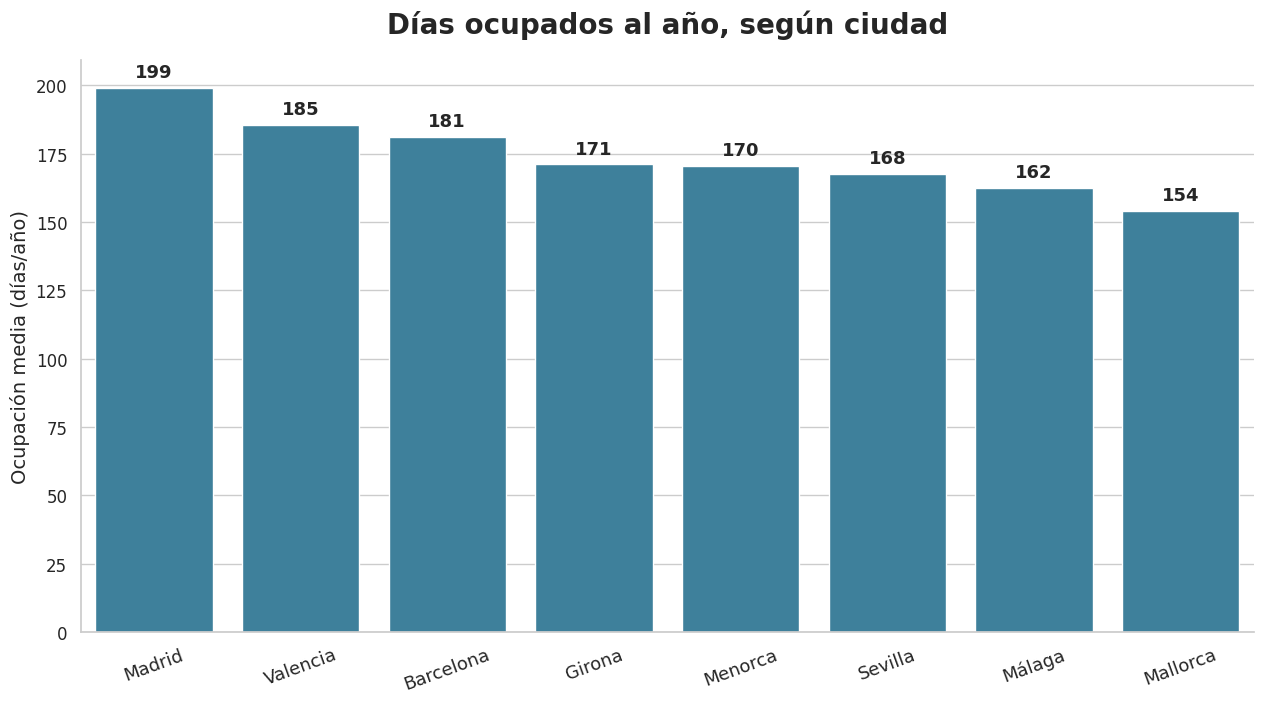

In [24]:
# GRÁFICO 1 — DISPONIBILIDAD MEDIA POR CIUDAD (VISTA GENERAL)
ocupacion_ciudad_canva = (
    df_ocupacion
    .groupby("city")["occupancy_365"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12.8, 7.2))

colores = ["#2E86AB"] * len(ocupacion_ciudad_canva)

sns.barplot(
    x=ocupacion_ciudad_canva.index,
    y=ocupacion_ciudad_canva.values,
    palette=colores,
    ax=ax
)

for i, valor in enumerate(ocupacion_ciudad_canva.values):
    ax.text(i, valor + 4, f"{valor:.0f}", ha="center",
            fontsize=13, weight="bold")

ax.set_title("Días ocupados al año, según ciudad", fontsize=20, weight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Ocupación media (días/año)", fontsize=14)
ax.tick_params(axis="x", labelsize=13, rotation=20)
ax.tick_params(axis="y", labelsize=12)
sns.despine()

plt.tight_layout()
plt.savefig("../Results/canva_01_ocupacion_por_ciudad.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Por qué este gráfico va primero:** da el contexto general antes de
entrar en la reserva automática. Madrid y Valencia son las ciudades
con más días ocupados al año (~199 y ~185 días), y Mallorca la que
menos (~154 días). Sin este punto de partida, sería difícil valorar
si una diferencia de, por ejemplo, 15 días según reserva automática
es mucha o poca en cada ciudad.

### Diapositiva 1, gráfico 2: ocupación según reserva automática, por ciudad

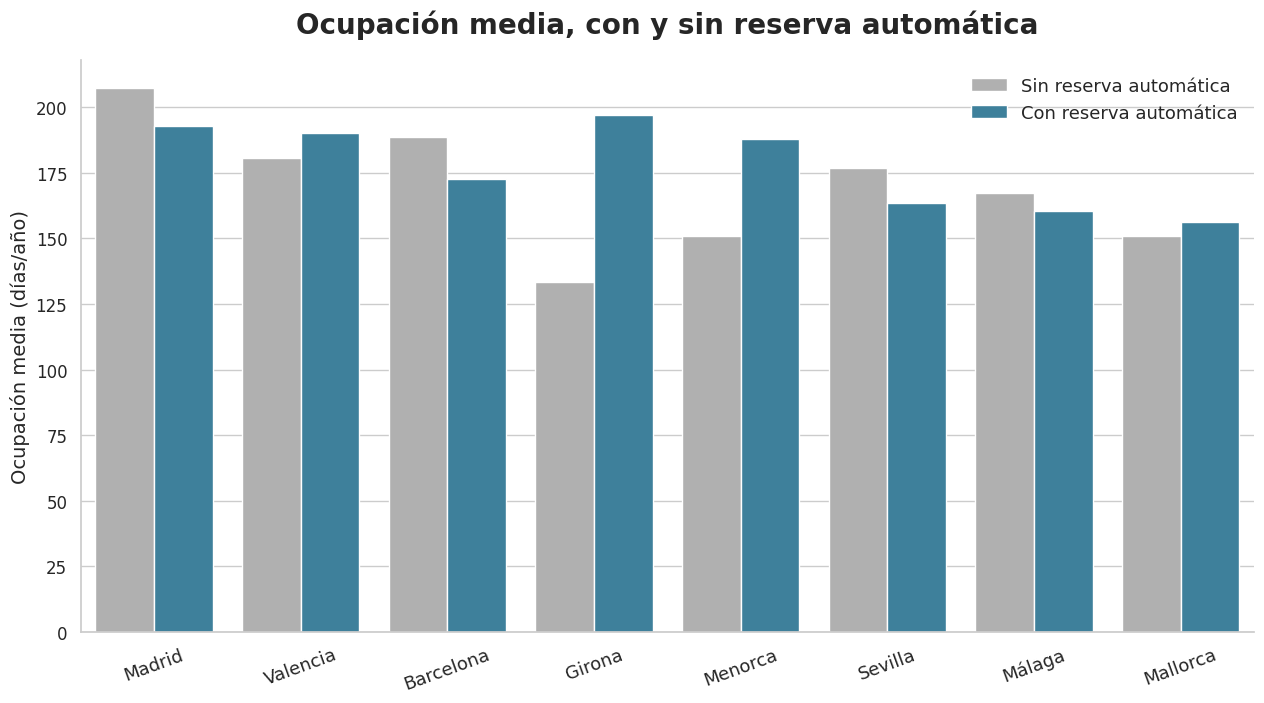

In [25]:
# GRÁFICO 2 — OCUPACIÓN SEGÚN RESERVA AUTOMÁTICA, POR CIUDAD
orden_ciudades = ocupacion_ciudad_canva.index.tolist()

fig, ax = plt.subplots(figsize=(12.8, 7.2))

sns.barplot(
    data=df_ocupacion,
    x="city",
    y="occupancy_365",
    hue="is_instant_bookable_numeric",
    estimator="mean",
    errorbar=None,
    order=orden_ciudades,
    palette=["#B0B0B0", "#2E86AB"],
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Sin reserva automática", "Con reserva automática"],
          fontsize=13, frameon=False, loc="upper right")

ax.set_title("Ocupación media, con y sin reserva automática",
             fontsize=20, weight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Ocupación media (días/año)", fontsize=14)
ax.tick_params(axis="x", labelsize=13, rotation=20)
ax.tick_params(axis="y", labelsize=12)
sns.despine()

plt.tight_layout()
plt.savefig("../Results/canva_02_ocupacion_instant_book_ciudad.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Por qué este gráfico va segundo:** es la primera respuesta directa
a la pregunta de negocio, ciudad por ciudad. Ya se aprecia aquí que
la barra gris (sin reserva automática) y la azul (con reserva
automática) no siempre se mueven en la misma dirección: en algunas
ciudades la reserva automática coincide con más ocupación, y en
otras con menos. El siguiente gráfico aísla esa diferencia para
verla con más claridad.

### Diapositiva 2, gráfico 3: dónde marca la diferencia la reserva automática

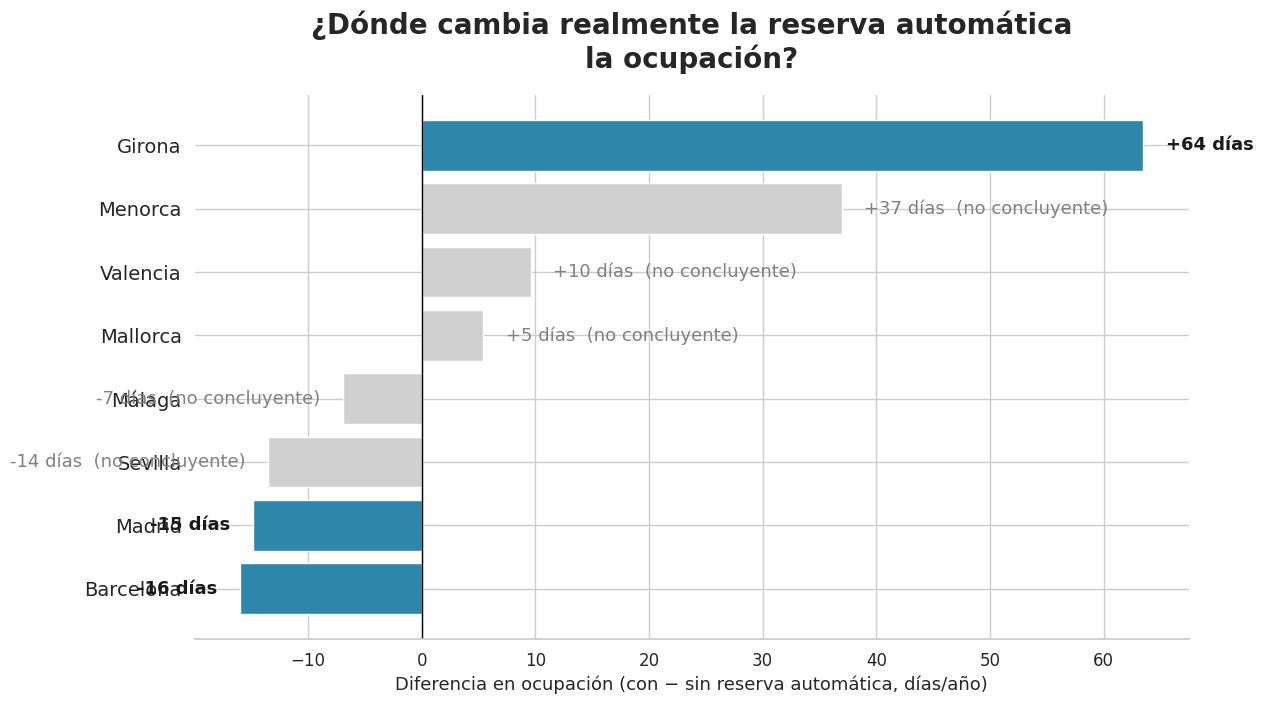

In [26]:
# GRÁFICO 3 — DIFERENCIA EN OCUPACIÓN SEGÚN RESERVA AUTOMÁTICA
from scipy import stats as sps

filas = []
for city, grupo in df_ocupacion.groupby("city"):
    con = grupo[grupo["is_instant_bookable_numeric"] == 1]["occupancy_365"]
    sin = grupo[grupo["is_instant_bookable_numeric"] == 0]["occupancy_365"]
    if len(con) > 5 and len(sin) > 5:
        _, p = sps.ttest_ind(con, sin, equal_var=False)
        filas.append({
            "city": city,
            "diferencia": con.mean() - sin.mean(),
            "significativa": p < 0.05
        })

dif_ocupacion = pd.DataFrame(filas).sort_values("diferencia")

fig, ax = plt.subplots(figsize=(12.8, 7.2))

colores = dif_ocupacion.apply(
    lambda r: "#2E86AB" if r["significativa"] else "#D0D0D0", axis=1
)

ax.barh(dif_ocupacion["city"], dif_ocupacion["diferencia"],
        color=colores)
ax.axvline(0, color="black", linewidth=1)

for i, (valor, sig) in enumerate(
    zip(dif_ocupacion["diferencia"], dif_ocupacion["significativa"])
):
    etiqueta = f"{valor:+.0f} días" + ("" if sig else "  (no concluyente)")
    ax.text(valor + (2 if valor >= 0 else -2), i, etiqueta,
            va="center", ha="left" if valor >= 0 else "right",
            fontsize=13, weight="bold" if sig else "normal",
            color="#1a1a1a" if sig else "#808080")

ax.set_title("¿Dónde cambia realmente la reserva automática\nla ocupación?",
             fontsize=20, weight="bold", pad=20)
ax.set_xlabel("Diferencia en ocupación (con − sin reserva automática, días/año)",
              fontsize=13)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=14)
ax.tick_params(axis="x", labelsize=12)
sns.despine(left=True)

plt.tight_layout()
plt.savefig("../Results/canva_03_diferencia_significativa_ciudad.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Por qué este gráfico es el más importante de la presentación (el
"zoom" principal):** en azul se destacan las únicas diferencias que
son estadísticamente sólidas; en gris, las que no se pueden
distinguir del azar y no conviene usar como argumento. Con los datos
actuales: en **Girona**, los alojamientos con reserva automática
tienen unos 64 días **más** de ocupación al año; en **Barcelona** y
**Madrid** ocurre lo contrario, con 15-16 días **menos** de
ocupación. El resto de ciudades no muestra una diferencia que se
pueda defender con seguridad, dado el tamaño de muestra disponible.

### Diapositiva 2, gráfico 4: tamaño de muestra por ciudad (para leer el gráfico anterior con contexto)

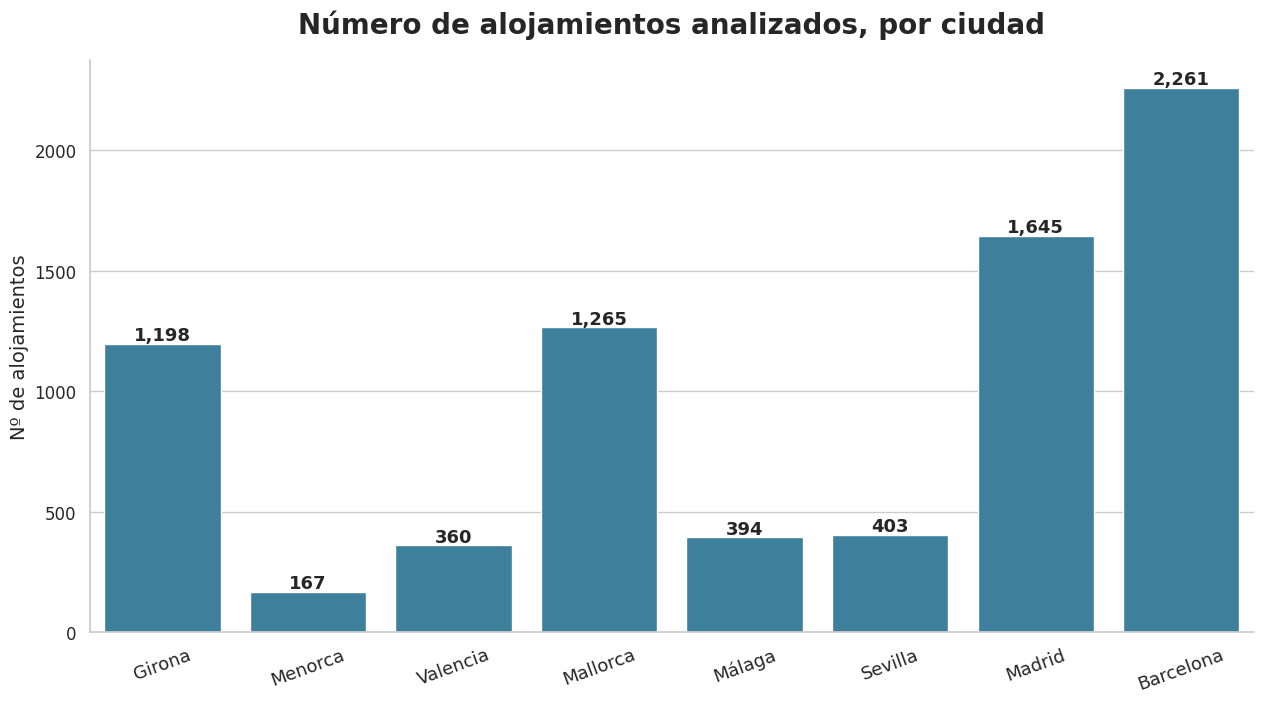

In [27]:
# GRÁFICO 4 — NÚMERO DE ALOJAMIENTOS ANALIZADOS, POR CIUDAD
n_ciudad = df_ocupacion["city"].value_counts().reindex(
    dif_ocupacion.sort_values("diferencia", ascending=False)["city"]
)

fig, ax = plt.subplots(figsize=(12.8, 7.2))

sns.barplot(x=n_ciudad.index, y=n_ciudad.values, color="#2E86AB", ax=ax)

for i, valor in enumerate(n_ciudad.values):
    ax.text(i, valor + 15, f"{valor:,}", ha="center", fontsize=13, weight="bold")

ax.set_title("Número de alojamientos analizados, por ciudad",
             fontsize=20, weight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Nº de alojamientos", fontsize=14)
ax.tick_params(axis="x", labelsize=13, rotation=20)
ax.tick_params(axis="y", labelsize=12)
sns.despine()

plt.tight_layout()
plt.savefig("../Results/canva_04_tamano_muestra_ciudad.png",
            dpi=150, bbox_inches="tight")
plt.show()

**Por qué acompaña al gráfico anterior:** ayuda a leer el hallazgo
con honestidad. Girona (1.198) y Barcelona (2.261) tienen muestras
amplias, lo que refuerza la solidez de sus diferencias (la más
grande a favor, Girona, y una de las más claras en contra,
Barcelona). Madrid (1.645) también tiene una muestra grande. En
cambio, ciudades con pocos alojamientos, como Menorca (167), piden
más cautela antes de sacar conclusiones definitivas.

### Plan de diapositivas y notas para la presentación

| Diapositiva | Gráficos | Mensaje central |
|---|---|---|
| 1 | Gráfico 1 + Gráfico 2 | Contexto general de ocupación por ciudad, y primera comparación con/sin reserva automática |
| 2 | Gráfico 3 + Gráfico 4 | Dónde hay una diferencia real (Girona, Barcelona, Madrid) y con qué fiabilidad (tamaño de muestra) |

**Propuesta de cierre con llamada a la acción concreta:** con base en
el gráfico 3, proponer al equipo de Operaciones **activar o
promocionar la reserva automática de forma prioritaria en Girona**,
donde se asocia con un aumento de ocupación de unos 64 días al año;
y revisar con más detalle **por qué en Barcelona y Madrid ocurre lo
contrario**, antes de aplicar la misma recomendación en esas dos
ciudades.

**Notas rápidas para la presentación en vivo** (a partir de la
revisión del equipo):
- Mostrar primero el gráfico y dejar que se vea antes de empezar a
  explicarlo.
- Usar los términos correctos al hablar de resultados estadísticos
  (muestra, significancia, sesgo), sin simplificarlos de más.
- Si surge una pregunta sobre un análisis que no está aquí, se puede
  responder que queda como propuesta de análisis futuro (por ejemplo,
  el modelo con interacción ciudad × Instant Book mencionado en la
  sección 7), en vez de improvisar un análisis nuevo en el momento.
- Contestar solo lo que se pregunta, sin extenderse a otros temas.

## 12. Resumen de cambios respecto al notebook anterior

Este notebook (`análisis_operaciones_gestión_inventario_06_07_2026.ipynb`)
retoma el notebook de análisis de reserva automática y ocupación por
ciudad, y añade lo siguiente respecto a la versión anterior:

- **Nombre de archivo actualizado** a
  `análisis_operaciones_gestión_inventario_06_07_2026.ipynb`, en
  línea con la convención de nombres del equipo (`DD_MM_YYYY`).
- **Interpretación de cada gráfico ampliada y hecha más específica**:
  todos los comentarios de la sección de EDA, VIF, modelo, supuestos
  y robustez incluyen ahora cifras concretas (medias, diferencias,
  p-valores, tamaños de muestra) en vez de descripciones genéricas,
  para que cada gráfico se pueda explicar con datos precisos en la
  presentación.
- **Evaluación explícita de la reducción de datos (sección 6)**: en
  vez de aplicar un data reduction por rutina, se compara el peso en
  memoria de `df` completo frente a `df_modelo`, y se argumenta por
  qué, para esta pregunta de negocio concreta, no aporta una ventaja
  real (y sí podría quitarle utilidad al `df` completo para otras
  preguntas de negocio del sprint). Se decide no aplicarla.
- **Nueva sección de propuestas de visualización (sección 11)**: 4
  gráficos organizados en 2 diapositivas (máximo 2 gráficos por
  diapositiva), pensados para un público no experto en datos, con
  texto mínimo y un mensaje central por gráfico. Incluye un plan de
  diapositivas y una propuesta de cierre con llamada a la acción
  concreta (Girona como prioridad).
- **Métrica de las visualizaciones corregida a ocupación**: la
  primera versión de estos 4 gráficos se había expresado en términos
  de disponibilidad; se han vuelto a generar en términos de
  **ocupación**, para mantener la misma métrica que se usa en el
  resto del notebook y en el modelo de regresión.
- **Notas de presentación incorporadas**: un resumen breve de buenas
  prácticas para la presentación en vivo (mostrar el gráfico antes de
  explicar, responder solo lo preguntado, dejar los análisis
  adicionales como propuestas futuras).

Lo que se mantiene igual respecto a la versión anterior: la lógica de
carga de datos, la construcción de las variables de ocupación, la
selección de variables del modelo, la estructura del modelo de
regresión final y la comprobación de robustez en los cuatro plazos.